In [3]:
#Boilerplate
from pathlib import Path
#General
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Analysis module
import evaluation_tools.inc_learn_tests as st

In [4]:

#Here's what we're testing
results = {'logistic': pd.DataFrame, 'svm':pd.DataFrame, 'xgboost':pd.DataFrame}

In [5]:
def inc_base_reader(num_tests:int, result_dict:dict):
    for clf, _ in result_dict.items():
        results_dir = Path.cwd() / 'results' / 'big_init_chunk' / f"{clf}"
        inc_test_results = []
        inc_train_results = []
        baseline_results = []
        for i in range(num_tests):
            inc_test_file = results_dir / f"{clf}_inc_batch{i}_test_accuracy.csv"
            inc_test_df = pd.read_csv(inc_test_file, index_col=0)
            inc_test_acc = inc_test_df.loc['accuracy'].iloc[0]
            inc_test_results.append(inc_test_acc)

            inc_train_file = results_dir / f"{clf}_inc_batch{i}_train_accuracy.csv"
            inc_train_df = pd.read_csv(inc_train_file, index_col=0)
            inc_train_acc = inc_train_df.loc['accuracy'].iloc[0]
            inc_train_results.append(inc_train_acc)
            
            baseline_file = results_dir / f"{clf}_base_batch{i}_test_accuracy.csv"
            baseline_df = pd.read_csv(baseline_file, index_col=0)
            baseline_acc = baseline_df.loc['accuracy'].iloc[0]
            baseline_results.append(baseline_acc)
            
        inc_test_df = pd.DataFrame(inc_test_results, columns=[f"{clf}_inc_test_accuracy"])
        inc_train_df = pd.DataFrame(inc_train_results, columns=[f"{clf}_inc_train_accuracy"])
        base_df = pd.DataFrame(baseline_results, columns=[f"{clf}_baseline_test_accuracy"])
        results = pd.concat([inc_test_df, inc_train_df, base_df], axis=1)
        
        result_dict[clf] = results
    return result_dict



In [6]:
results = inc_base_reader(5, results)

In [7]:
results['xgboost']

,xgboost_inc_test_accuracy,xgboost_inc_train_accuracy,xgboost_baseline_test_accuracy
0,0.803191,0.611044,0.803191
1,0.604278,0.787234,0.459893
2,0.718085,0.764706,0.484043
3,0.768817,0.813830,0.467742
4,0.778378,0.790323,0.567568


In [8]:
full_results = pd.concat(results, axis=1).droplevel(level=0, axis=1)

In [7]:
#Setup the variables
# cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=0)
basics = st.TestVariables(full_results)
rope_interval = [-0.01, 0.01]

### Proof of Point

### Pairwise Frequentist

In [8]:
pairwise_comp_df = st.pairwise_freq(model_scores=basics.model_scores, num_tests=basics.num_tests, pairwise_comp_df=None)

In [9]:
# pairwise_comp_df.sort_values(['p_val', 't_stat'])

### Pairwise Bayesian

In [10]:
pairwise_comp_df = st.pairwise_bayesian(model_scores=basics.model_scores, rope_interval=rope_interval, num_tests=basics.num_tests, h=1, pairwise_comp_df=pairwise_comp_df)

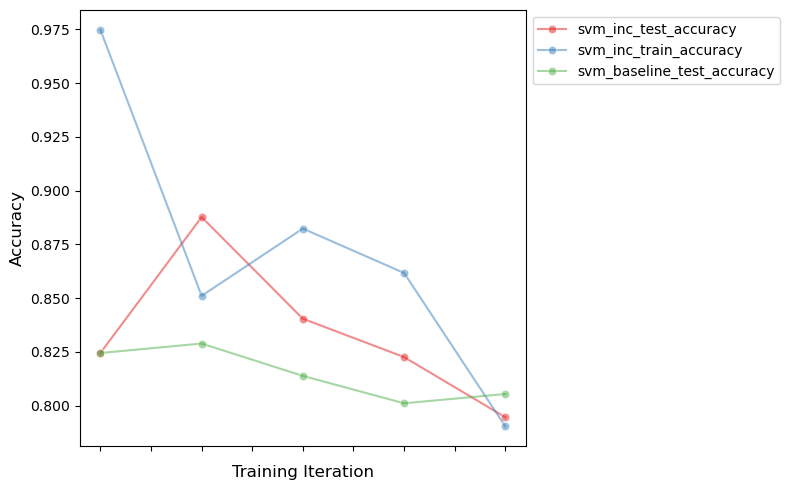

Correlation of models:
 


,logistic_inc_test_accuracy,logistic_inc_train_accuracy,logistic_baseline_test_accuracy,svm_inc_test_accuracy,svm_inc_train_accuracy,svm_baseline_test_accuracy,xgboost_inc_test_accuracy,xgboost_inc_train_accuracy,xgboost_baseline_test_accuracy
logistic_inc_test_accuracy,1.000000,-0.915033,0.363091,0.094271,-0.878510,-0.472073,-0.443875,0.955859,-0.922437
logistic_inc_train_accuracy,-0.915033,1.000000,-0.274176,-0.375284,0.840888,0.208222,0.688435,-0.932794,0.926337
logistic_baseline_test_accuracy,0.363091,-0.274176,1.000000,0.440346,-0.111500,0.379301,-0.549530,0.105945,-0.315896
svm_inc_test_accuracy,0.094271,-0.375284,0.440346,1.000000,0.141638,0.724255,-0.910124,0.098607,-0.375098
svm_inc_train_accuracy,-0.878510,0.840888,-0.111500,0.141638,1.000000,0.500706,0.268326,-0.865462,0.689537
svm_baseline_test_accuracy,-0.472073,0.208222,0.379301,0.724255,0.500706,1.000000,-0.539291,-0.536900,0.320628
xgboost_inc_test_accuracy,-0.443875,0.688435,-0.549530,-0.910124,0.268326,-0.539291,1.000000,-0.413973,0.615851
xgboost_inc_train_accuracy,0.955859,-0.932794,0.105945,0.098607,-0.865462,-0.536900,-0.413973,1.000000,-0.938197
xgboost_baseline_test_accuracy,-0.922437,0.926337,-0.315896,-0.375098,0.689537,0.320628,0.615851,-0.938197,1.000000


In [13]:
# plot 30 examples of dependency between cv fold and AUC scores
fig, ax = plt.subplots(figsize=(8, 5))  # slightly wider figure gives room
sns.lineplot(
    data=basics.model_scores.iloc[3:6].transpose(),
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

# Move legend outside the plot area to the right
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

ax.set_xlabel("Training Iteration", size=12, labelpad=10)
ax.set_ylabel("Accuracy", size=12)
ax.tick_params(bottom=True, labelbottom=False)

plt.tight_layout()  # prevents legend text from getting clipped
plt.show()

# print correlation of AUC scores across folds
print(f"Correlation of models:\n ")
pd.DataFrame(basics.model_scores.head(20).transpose().corr())

### Interpretation Notes
 - Null Hypothesis is that the two models have the same loss. 
 - Loss Differential (d)=Model 1 Error−Model 2 Error. So a negitive t_stat means that model 2 has higher loss than model 1. 

In [16]:
pairwise_comp_df.sort_values(['model_1', 'model_2'], ascending=True).dropna().iloc[20:25]

,model_1,model_2,t_stat,p_val,worse_prob,better_prob,rope_prob
13,logistic_inc_train_accuracy,xgboost_inc_train_accuracy,-0.717,1.000,0.157,0.635,0.208
32,svm_baseline_test_accuracy,xgboost_baseline_test_accuracy,-3.812,0.093,0.002,0.997,0.002
30,svm_baseline_test_accuracy,xgboost_inc_test_accuracy,-1.819,1.000,0.027,0.897,0.076
31,svm_baseline_test_accuracy,xgboost_inc_train_accuracy,-1.399,1.000,0.051,0.817,0.132
22,svm_inc_test_accuracy,svm_baseline_test_accuracy,-1.610,1.000,0.001,0.150,0.848


## Generalizability 

In [9]:
full_results

,logistic_inc_test_accuracy,logistic_inc_train_accuracy,logistic_baseline_test_accuracy,svm_inc_test_accuracy,svm_inc_train_accuracy,svm_baseline_test_accuracy,xgboost_inc_test_accuracy,xgboost_inc_train_accuracy,xgboost_baseline_test_accuracy
0,0.686170,0.853541,0.686170,0.824468,0.974790,0.824468,0.803191,0.611044,0.803191
1,0.764706,0.750000,0.700535,0.887701,0.851064,0.828877,0.604278,0.787234,0.459893
2,0.771277,0.786096,0.712766,0.840426,0.882353,0.813830,0.718085,0.764706,0.484043
3,0.763441,0.776596,0.677419,0.822581,0.861702,0.801075,0.768817,0.813830,0.467742
4,0.772973,0.774194,0.691892,0.794595,0.790323,0.805405,0.778378,0.790323,0.567568


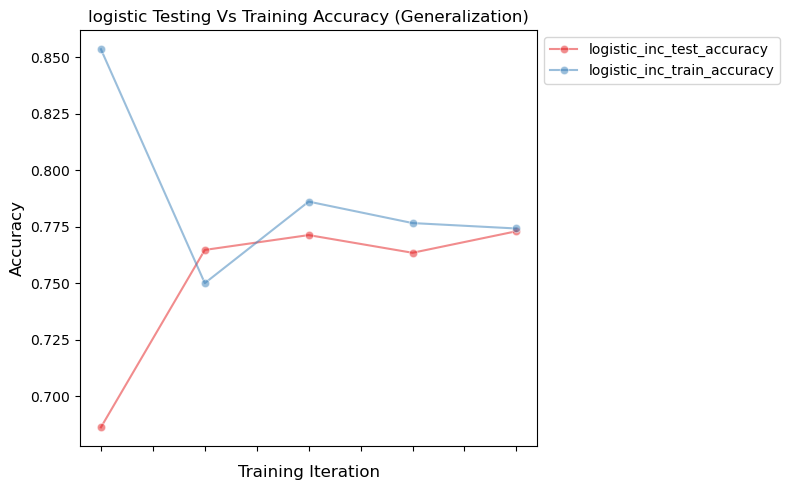

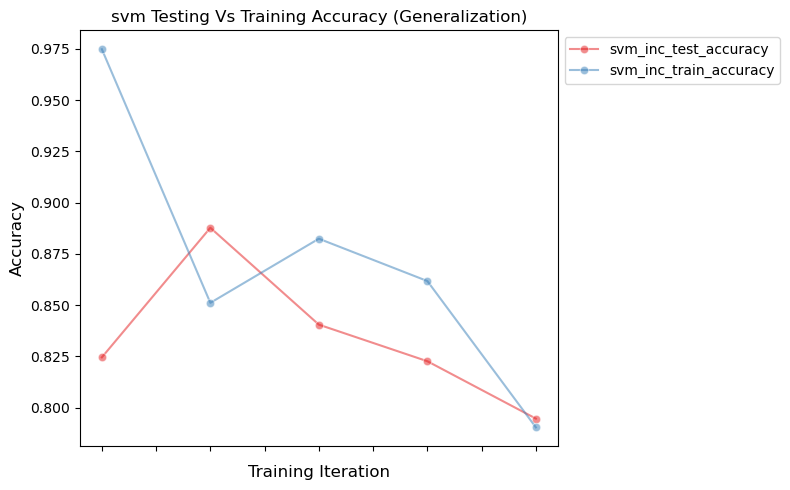

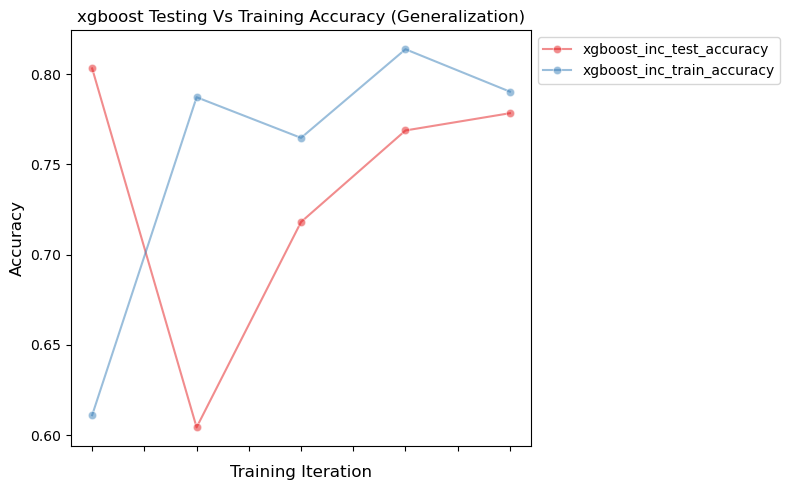

In [15]:
def overfitting_plt(model:str):
    compare = full_results[[f"{model}_inc_test_accuracy", f"{model}_inc_train_accuracy"]]
# plot 30 examples of dependency between cv fold and AUC scores
    fig, ax = plt.subplots(figsize=(8, 5))  # slightly wider figure gives room
    sns.lineplot(
    data=compare,
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)

# Move legend outside the plot area to the right
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    ax.set_xlabel("Training Iteration", size=12, labelpad=10)
    ax.set_ylabel("Accuracy", size=12)
    ax.tick_params(bottom=True, labelbottom=False)
    ax.set_title(f"{model} Testing Vs Training Accuracy (Generalization)")

    plt.tight_layout()  # prevents legend text from getting clipped
    plt.show()

for clf in results.keys():
    overfitting_plt(clf)